# Ejercicio práctico: RAG sobre un PDF

Este cuaderno complementa `sesion_03.ipynb` y te guía para construir un flujo de Retrieval-Augmented Generation (RAG) sobre un documento PDF situado en `inputs/faqs.pdf`.
Solo la carga del PDF está resuelta; el resto de celdas de código quedan completadas aquí como posible solución.

## 0. Requisitos previos
- Python ≥ 3.9 y el kernel correcto seleccionado.
- Clave activa en Google AI Studio (`GOOGLE_API_KEY`) cargada como variable de entorno.
- Librerías recomendadas: `langchain-text-splitters`, `langchain-community`, `langgraph`, `langchain-google-genai`, `langchain-core`, `pypdf`, `python-dotenv`.
- Este notebook asume una GPU/CPU estándar; ajusta tamaños de `chunk` si lo necesitas.

In [ ]:
# Instala o actualiza las dependencias necesarias para el ejercicio.
%pip install -q -U langchain-text-splitters langchain-community langgraph langchain-google-genai langchain-core pypdf python-dotenv


## 1. Configuración de claves y modelos
Carga tus variables de entorno y prepara los modelos que reutilizarás en el resto del cuaderno.

In [1]:
import getpass, os
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.chat_models import init_chat_model

load_dotenv()

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
llm = init_chat_model("gemini-2.0-flash", model_provider="google_genai")

print("Embeddings y LLM listos.")


Embeddings y LLM listos.


## 2. Carga del PDF (implementada)
El documento de trabajo está en `inputs/faqs.pdf`. Usa esta celda como punto de partida para generar tus chunks y continuar con el flujo RAG.

In [2]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

pdf_path = Path("inputs/faqs.pdf")
if not pdf_path.exists():
    raise FileNotFoundError(f"No se encontró el PDF en {pdf_path.resolve()}")

loader = PyPDFLoader(str(pdf_path))
docs = loader.load()

print(f"Documentos cargados: {len(docs)} (una entrada por página).")
print(f"Longitud de la primera página: {len(docs[0].page_content)} caracteres")
print("\nMuestra del contenido de la primera página:")
print(docs[0].page_content[:800])


Documentos cargados: 2 (una entrada por página).
Longitud de la primera página: 1433 caracteres

Muestra del contenido de la primera página:
Base de Conocimiento para Q&A Interno de la Empresa
Sección de Preguntas Frecuentes (FAQs) Detallada
Pregunta: ¿Cómo puedo acceder al portal de empleados desde casa?
Respuesta: 
    Para acceder al portal de empleados desde casa, sigue estos pasos:
    1. Asegúrate de tener una conexión a internet segura.
    2. Utiliza la VPN de la empresa para una conexión segura.
    3. Accede a la página del portal de empleados en: http://portal.empleados.com.
    4. Introduce tu nombre de usuario y contraseña.
    Si tienes problemas para acceder, contacta al soporte técnico.
Pregunta: ¿Qué debo hacer si olvido mi contraseña del correo electrónico corporativo?
Respuesta: 
    Si olvidas tu contraseña del correo electrónico corporativo, puedes restablecerla siguiendo estos
pasos:
    1. Ve a la página 


## 3. Explora el dataset
Revisa el contenido y metadatos del PDF para decidir cómo trocearlo. Puedes imprimir las claves de `metadata` o contar palabras por página.

In [3]:
from collections import Counter

print(f"Total páginas: {len(docs)}")
print("Metadata de la primera página:", docs[0].metadata)
lengths = [len(d.page_content) for d in docs]
print(f"Longitud media por página: {sum(lengths)/len(lengths):.1f} caracteres")
print(f"Longitud máxima: {max(lengths)} - mínima: {min(lengths)}")


Total páginas: 2
Metadata de la primera página: {'producer': 'PyFPDF 1.7.2 http://pyfpdf.googlecode.com/', 'creator': 'PyPDF', 'creationdate': 'D:20240319110349', 'source': 'inputs/faqs.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}
Longitud media por página: 1220.5 caracteres
Longitud máxima: 1433 - mínima: 1008


## 4. Troceo del documento
Usa `RecursiveCharacterTextSplitter` (o la técnica de tu preferencia) para crear chunks con solapamiento. Ajusta `chunk_size` y `chunk_overlap` según el contenido.

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True,
)
all_splits = text_splitter.split_documents(docs)

print(f"Chunks generados: {len(all_splits)}")
print("Ejemplo primer chunk:")
print(all_splits[0].page_content)


Chunks generados: 4
Ejemplo primer chunk:
Base de Conocimiento para Q&A Interno de la Empresa
Sección de Preguntas Frecuentes (FAQs) Detallada
Pregunta: ¿Cómo puedo acceder al portal de empleados desde casa?
Respuesta: 
    Para acceder al portal de empleados desde casa, sigue estos pasos:
    1. Asegúrate de tener una conexión a internet segura.
    2. Utiliza la VPN de la empresa para una conexión segura.
    3. Accede a la página del portal de empleados en: http://portal.empleados.com.
    4. Introduce tu nombre de usuario y contraseña.
    Si tienes problemas para acceder, contacta al soporte técnico.
Pregunta: ¿Qué debo hacer si olvido mi contraseña del correo electrónico corporativo?
Respuesta: 
    Si olvidas tu contraseña del correo electrónico corporativo, puedes restablecerla siguiendo estos
pasos:
    1. Ve a la página de inicio de sesión del correo y haz clic en "Olvidé mi contraseña".
    2. Sigue las instrucciones para restablecerla, que pueden incluir responder a pregunt

## 5. Indexación: embeddings y vector store
Crea las incrustaciones con Gemini y guarda los chunks en una `InMemoryVectorStore` (o cualquier store compatible) para poder hacer búsquedas por similaridad.

In [5]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)
doc_ids = vector_store.add_documents(all_splits)

print(f"Documentos indexados: {len(doc_ids)}")


Documentos indexados: 4


## 6. Prompt para question answering
Define un prompt conciso que use el contexto recuperado y la pregunta del usuario. Reutiliza el patrón visto en la sesión: máximo de frases, reconoce cuando no hay respuesta, etc.

In [6]:
from langchain_core.prompts import PromptTemplate, MessagesPlaceholder

prompt = PromptTemplate.from_template(
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question}\n"
    "Context: {context}\n"
    "Answer: "
)

example = prompt.invoke({"question": "(pregunta de ejemplo)", "context": "(contexto de ejemplo)"})
print(example.text)


You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (pregunta de ejemplo)
Context: (contexto de ejemplo)
Answer: 


## 7. Cadena RAG mínima
Implementa una primera versión sin LangGraph:
1. Define una pregunta de prueba.
2. Recupera los `k` chunks más similares.
3. Formatea el contexto y llama al modelo de chat para obtener la respuesta.

In [7]:
question = "¿Qué información clave aparece en el PDF?"
retrieved_docs = vector_store.similarity_search(question, k=3)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

print("Contexto recuperado (resumen):\n")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"Chunk {i} metadata: {doc.metadata}")
    print(doc.page_content[:400], "\n---\n")

messages = prompt.invoke({"question": question, "context": docs_content})
response = llm.invoke(messages)

print("Respuesta del modelo:\n", response.content)


Contexto recuperado (resumen):

Chunk 1 metadata: {'producer': 'PyFPDF 1.7.2 http://pyfpdf.googlecode.com/', 'creator': 'PyPDF', 'creationdate': 'D:20240319110349', 'source': 'inputs/faqs.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'start_index': 0}
Base de Conocimiento para Q&A Interno de la Empresa
Sección de Preguntas Frecuentes (FAQs) Detallada
Pregunta: ¿Cómo puedo acceder al portal de empleados desde casa?
Respuesta: 
    Para acceder al portal de empleados desde casa, sigue estos pasos:
    1. Asegúrate de tener una conexión a internet segura.
    2. Utiliza la VPN de la empresa para una conexión segura.
    3. Accede a la página del p 
---

Chunk 2 metadata: {'producer': 'PyFPDF 1.7.2 http://pyfpdf.googlecode.com/', 'creator': 'PyPDF', 'creationdate': 'D:20240319110349', 'source': 'inputs/faqs.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'start_index': 782}
1. Ve a la página de inicio de sesión del correo y haz clic en "Olvidé mi contraseña".
    2. Sigue las

## 8. Grafo con LangGraph
Repite el flujo anterior usando LangGraph para separar responsabilidades (por ejemplo, `retrieve` y `generate`).
Sugerencia: crea un `State` (TypedDict) que contenga al menos la pregunta, el contexto y la respuesta.

In [8]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict

class State(TypedDict):
    question: str
    context: List[Document]
    prompt: str
    answer: str

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"], k=5)
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content, "prompt": messages.text}


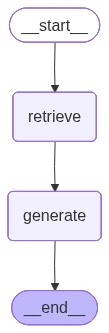

Prompt:
 You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: Resume el contenido clave del PDF
Context: Base de Conocimiento para Q&A Interno de la Empresa
Sección de Preguntas Frecuentes (FAQs) Detallada
Pregunta: ¿Cómo puedo acceder al portal de empleados desde casa?
Respuesta: 
    Para acceder al portal de empleados desde casa, sigue estos pasos:
    1. Asegúrate de tener una conexión a internet segura.
    2. Utiliza la VPN de la empresa para una conexión segura.
    3. Accede a la página del portal de empleados en: http://portal.empleados.com.
    4. Introduce tu nombre de usuario y contraseña.
    Si tienes problemas para acceder, contacta al soporte técnico.
Pregunta: ¿Qué debo hacer si olvido mi contraseña del correo electrónico corporativo?
Respuesta: 
    Si olvidas tu contraseña de

In [9]:
from langgraph.graph import START, StateGraph
from IPython.display import Image, display

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({"question": "Resume el contenido clave del PDF"})
print("Prompt:\n", result["prompt"])
print("\nRespuesta:\n", result["answer"])


## 9. Conversacional y memoria (opcional)
Como extensión, añade gestión de mensajes con `MessagesState`, usa herramientas (por ejemplo, tu propio `retrieve`) y activa `MemorySaver` para mantener el hilo de la conversación.

In [10]:
from langgraph.graph import MessagesState, END
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

@tool(response_format="content_and_artifact")
def retrieve_tool(query: str):
    """Retrieve información relacionada con una query desde el vector store."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

def query_or_respond(state: MessagesState):
    llm_with_tools = llm.bind_tools([retrieve_tool])
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tools = ToolNode([retrieve_tool])

def generate(state: MessagesState):
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = list(reversed(recent_tool_messages))
    docs_content = "\n\n".join(msg.content for msg in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know. "
        "Use three sentences maximum and keep the answer concise."
        f"\n\n{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt_messages = [SystemMessage(system_message_content)] + conversation_messages
    final = llm.invoke(prompt_messages)
    return {"messages": [final]}

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("query_or_respond", query_or_respond)
graph_builder.add_node("tools", tools)
graph_builder.add_node("generate", generate)
graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond", tools_condition, {END: END, "tools": "tools"}
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()
conversational_graph = graph_builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "thread-1"}}
for step in conversational_graph.stream(
    {"messages": [{"role": "user", "content": "Dame un resumen breve del PDF."}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

Dame un resumen breve del PDF.
================================== Ai Message ==================================

Para poder darte un resumen, necesito que me digas qué información quieres que busque en el PDF.


---
Cuando completes el ejercicio, prueba varias preguntas (por ejemplo, dudas frecuentes del PDF) y observa cómo cambia la calidad de las respuestas al ajustar el tamaño de los chunks, el número de documentos recuperados o el prompt.

In [11]:
question = "¿Cómo puedo pedir las vacaciones?"
for step in conversational_graph.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

¿Cómo puedo pedir las vacaciones?
================================== Ai Message ==================================
Tool Calls:
  retrieve_tool (28c58549-0449-422d-8883-f3e984db843e)
 Call ID: 28c58549-0449-422d-8883-f3e984db843e
  Args:
    query: ¿Cómo puedo pedir las vacaciones?
================================= Tool Message =================================
Name: retrieve_tool

Source: {'producer': 'PyFPDF 1.7.2 http://pyfpdf.googlecode.com/', 'creator': 'PyPDF', 'creationdate': 'D:20240319110349', 'source': 'inputs/faqs.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'start_index': 782}
Content: 1. Ve a la página de inicio de sesión del correo y haz clic en "Olvidé mi contraseña".
    2. Sigue las instrucciones para restablecerla, que pueden incluir responder a preguntas de
seguridad.
    3. Recibirás un enlace de restablecimiento de contraseña en tu correo alternativo o por SMS.
    Para más ay